In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: NVIDIA RTX A2000 12GB


In [5]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

In [1]:
import zipfile
with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall()
print("Done extracting!")

Done extracting!


In [7]:
import os
for root, dirs, files in os.walk("data"):
    print(root, "→", len(files))

data → 0
data\test → 0
data\test\cats → 100
data\test\dogs → 100
data\train → 0
data\train\cats → 400
data\train\dogs → 400


In [9]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
train_data = datasets.ImageFolder("data/train", transform=transform)
test_data = datasets.ImageFolder("data/test", transform=transform)
print("Classes:", train_data.classes)

Classes: ['cats', 'dogs']


In [13]:
from torchvision import models
model = models.resnet18(pretrained=True)
print("Model loaded")

C:\Users\23adsb84\.conda\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\23adsb84\.conda\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\23adsb84/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


Model loaded


In [15]:
for param in model.parameters():
    param.requires_grad = False
print("Layers frozen")

Layers frozen


In [17]:
import torch.nn as nn
num_classes = len(train_data.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
print(model.fc)

Linear(in_features=512, out_features=2, bias=True)


In [19]:
model = model.to(device)

In [21]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [25]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True)
epochs = 50
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

Epoch 1/50, Loss: 7.8942
Epoch 2/50, Loss: 7.8420
Epoch 3/50, Loss: 5.5465
Epoch 4/50, Loss: 5.8441
Epoch 5/50, Loss: 5.6288
Epoch 6/50, Loss: 5.7300
Epoch 7/50, Loss: 4.9421
Epoch 8/50, Loss: 9.3496
Epoch 9/50, Loss: 4.2867
Epoch 10/50, Loss: 5.9239
Epoch 11/50, Loss: 5.3520
Epoch 12/50, Loss: 3.4373
Epoch 13/50, Loss: 6.5383
Epoch 14/50, Loss: 4.3224
Epoch 15/50, Loss: 3.6510
Epoch 16/50, Loss: 4.3062
Epoch 17/50, Loss: 4.3937
Epoch 18/50, Loss: 3.8388
Epoch 19/50, Loss: 4.1152
Epoch 20/50, Loss: 2.6930
Epoch 21/50, Loss: 3.8075
Epoch 22/50, Loss: 3.2875
Epoch 23/50, Loss: 3.8999
Epoch 24/50, Loss: 4.2473
Epoch 25/50, Loss: 3.4201
Epoch 26/50, Loss: 3.4761
Epoch 27/50, Loss: 2.6990
Epoch 28/50, Loss: 4.4515
Epoch 29/50, Loss: 2.6250
Epoch 30/50, Loss: 3.4463
Epoch 31/50, Loss: 5.1586
Epoch 32/50, Loss: 2.8767
Epoch 33/50, Loss: 2.2495
Epoch 34/50, Loss: 3.1639
Epoch 35/50, Loss: 4.2952
Epoch 36/50, Loss: 3.0017
Epoch 37/50, Loss: 3.2470
Epoch 38/50, Loss: 1.9738
Epoch 39/50, Loss: 3.

In [27]:
test_loader = torch.utils.data.DataLoader(test_data, batch_size=16)
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 95.5


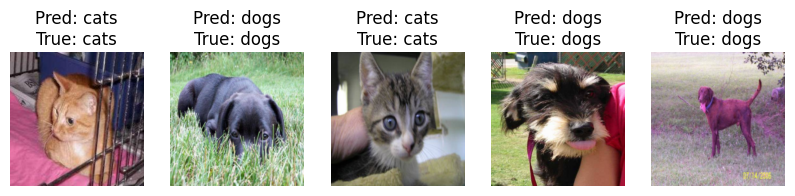

In [53]:
import random
indices = random.sample(range(len(test_data)), 5)
plt.figure(figsize=(10,4))
for i, idx in enumerate(indices):
    img, label = test_data[idx]
    input_img = img.unsqueeze(0).to(device)
    output = model(input_img)
    _, pred = torch.max(output, 1)
    plt.subplot(1,5,i+1)
    imshow(img)
    plt.title(f"Pred: {train_data.classes[pred]}\nTrue: {train_data.classes[label]}")
plt.show()

In [43]:
!pip install scikit-learn

In [45]:
from sklearn.metrics import confusion_matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [47]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[99  1]
 [ 8 92]]


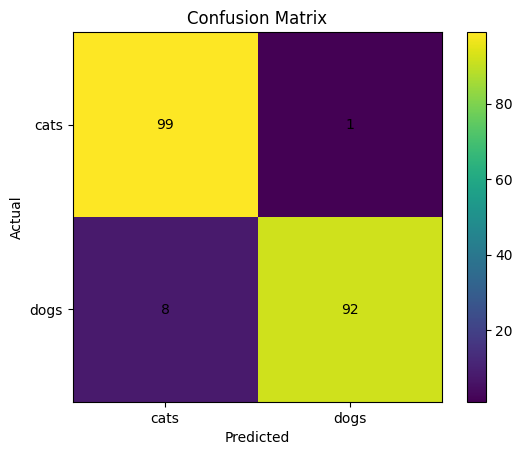

In [49]:
import matplotlib.pyplot as plt
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
classes = train_data.classes
tick_marks = range(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i][j], ha="center", va="center")
plt.show()

In [51]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

              precision    recall  f1-score   support

        cats       0.93      0.99      0.96       100
        dogs       0.99      0.92      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200

